In [1]:
from typing import TypedDict,Dict
from langgraph.graph import StateGraph


C:\Users\Deepp\AppData\Roaming\Python\Python314\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
import random

In [2]:
class AgentState(TypedDict):
    player_name: str
    guesses: list
    attempts: int
    lower_bound: int
    upper_bound: int
    hint: str
    current_guess: int
    secret_number: int

In [4]:
# Define node functions
def initialize_game(state: AgentState) -> AgentState:
    """Initialize the game with a secret number"""
    state["secret_number"] = random.randint(state["lower_bound"], state["upper_bound"])
    state["attempts"] = 0
    state["guesses"] = []
    state["hint"] = "Game started"
    return state

def make_guess(state: AgentState) -> AgentState:
    """Make a guess based on current bounds"""
    # Use binary search strategy
    guess = (state["lower_bound"] + state["upper_bound"]) // 2
    state["current_guess"] = guess
    state["guesses"].append(guess)
    state["attempts"] += 1
    return state

def check_guess(state: AgentState) -> AgentState:
    """Check the guess and provide hint"""
    guess = state["current_guess"]
    secret = state["secret_number"]
    
    if guess == secret:
        state["hint"] = "correct"
    elif guess < secret:
        state["hint"] = "higher"
        state["lower_bound"] = guess + 1
    else:
        state["hint"] = "lower"
        state["upper_bound"] = guess - 1
    
    return state

def should_continue(state: AgentState) -> str:
    """Determine if game should continue"""
    if state["hint"] == "correct":
        return "end"
    elif state["attempts"] >= 7:
        return "end"
    else:
        return "continue"

In [5]:
# Build the graph
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("initialize", initialize_game)
graph.add_node("guess", make_guess)
graph.add_node("check", check_guess)

# Add edges
graph.set_entry_point("initialize")
graph.add_edge("initialize", "guess")
graph.add_edge("guess", "check")

# Conditional edge based on game state
graph.add_conditional_edges(
    "check",
    should_continue,
    {
        "continue": "guess",
        "end": "__end__"
    }
)

# Compile the graph
game_graph = graph.compile()

In [6]:
# Test the game
initial_input = {
    "player_name": "Student",
    "guesses": [],
    "attempts": 0,
    "lower_bound": 1,
    "upper_bound": 20,
    "hint": "",
    "current_guess": 0,
    "secret_number": 0
}

result = game_graph.invoke(initial_input)

print(f"Player: {result['player_name']}")
print(f"Secret Number: {result['secret_number']}")
print(f"Guesses Made: {result['guesses']}")
print(f"Total Attempts: {result['attempts']}")
print(f"Final Result: {result['hint']}")
if result['hint'] == "correct":
    print(f"✓ Game Won in {result['attempts']} attempts!")
else:
    print(f"✗ Game Over - Max attempts reached")

Player: Student
Secret Number: 7
Guesses Made: [10, 5, 7]
Total Attempts: 3
Final Result: correct
✓ Game Won in 3 attempts!


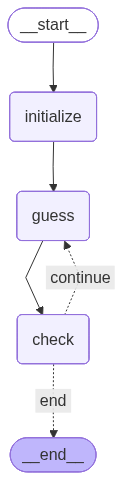

In [7]:
from IPython.display import display,Image
display(Image(game_graph.get_graph().draw_mermaid_png()))